import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt


# EDA

In [7]:
df = pd.read_csv ("Loan_Default.csv")

#Viewing Data

In [10]:
df.head() # show first five rows of data

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [12]:
df.tail() # show last five rows of data

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
148665,173555,2019,cf,Sex Not Available,nopre,type1,p3,l1,nopc,nob/c,...,CIB,659,EXP,55-64,to_inst,71.792763,south,direct,0,48.0
148666,173556,2019,cf,Male,nopre,type1,p1,l1,nopc,nob/c,...,CIB,569,CIB,25-34,not_inst,74.428934,south,direct,0,15.0
148667,173557,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,CIB,702,EXP,45-54,not_inst,61.332418,North,direct,0,49.0
148668,173558,2019,cf,Female,nopre,type1,p4,l1,nopc,nob/c,...,EXP,737,EXP,55-64,to_inst,70.683453,North,direct,0,29.0
148669,173559,2019,cf,Female,nopre,type1,p3,l1,nopc,nob/c,...,CIB,830,CIB,45-54,not_inst,72.849462,North,direct,0,44.0


In [14]:
df.shape #shows no of rows and columns

(148670, 34)

In [16]:
df.info() #shows datatypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

#Counting Numerical and categorical columns

In [18]:
num_cols = df.select_dtypes(include=['number']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))

Numerical columns: 13
Categorical columns: 21


#Find Values Count

In [27]:
cat_cols = df.select_dtypes(include=['object']).columns

def valuesCount(cat_cols):
    for col in cat_cols:
        print("\n--------------------")
        print("Column:", col)
        print("--------------------")
        print(df[col].value_counts())
       

In [28]:
valuesCount(cat_cols)


--------------------
Column: loan_limit
--------------------
loan_limit
cf     135348
ncf      9978
Name: count, dtype: int64

--------------------
Column: Gender
--------------------
Gender
Male                 42346
Joint                41399
Sex Not Available    37659
Female               27266
Name: count, dtype: int64

--------------------
Column: approv_in_adv
--------------------
approv_in_adv
nopre    124621
pre       23141
Name: count, dtype: int64

--------------------
Column: loan_type
--------------------
loan_type
type1    113173
type2     20762
type3     14735
Name: count, dtype: int64

--------------------
Column: loan_purpose
--------------------
loan_purpose
p3    55934
p4    54799
p1    34529
p2     3274
Name: count, dtype: int64

--------------------
Column: Credit_Worthiness
--------------------
Credit_Worthiness
l1    142344
l2      6326
Name: count, dtype: int64

--------------------
Column: open_credit
--------------------
open_credit
nopc    148114
opc        5

#Finding Missing Values

In [29]:
df.isnull().sum()

ID                               0
year                             0
loan_limit                    3344
Gender                           0
approv_in_adv                  908
loan_type                        0
loan_purpose                   134
Credit_Worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
Interest_rate_spread         36639
Upfront_charges              39642
term                            41
Neg_ammortization              121
interest_only                    0
lump_sum_payment                 0
property_value               15098
construction_type                0
occupancy_type                   0
Secured_by                       0
total_units                      0
income                        9150
credit_type                      0
Credit_Score                     0
co-applicant_credit_type         0
age                            200
submission_of_applic

#Statistical Analysis

In [32]:
df.describe() #Only for numerical Columns

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,148670.000000,148670.0,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,139520.000000,148670.000000,133572.000000,148670.000000,124549.000000
mean,99224.500000,2019.0,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,42917.476598,0.0,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6496.586382,115.875857,39.967603,0.430942,10.545435
min,24890.000000,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,62057.250000,2019.0,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,99224.500000,2019.0,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,136391.750000,2019.0,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,173559.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


#Visulization:
Numerical distributions → histograms
Categorical distributions → count plots
Outliers → boxplots
Target (Status) distribution → count plot

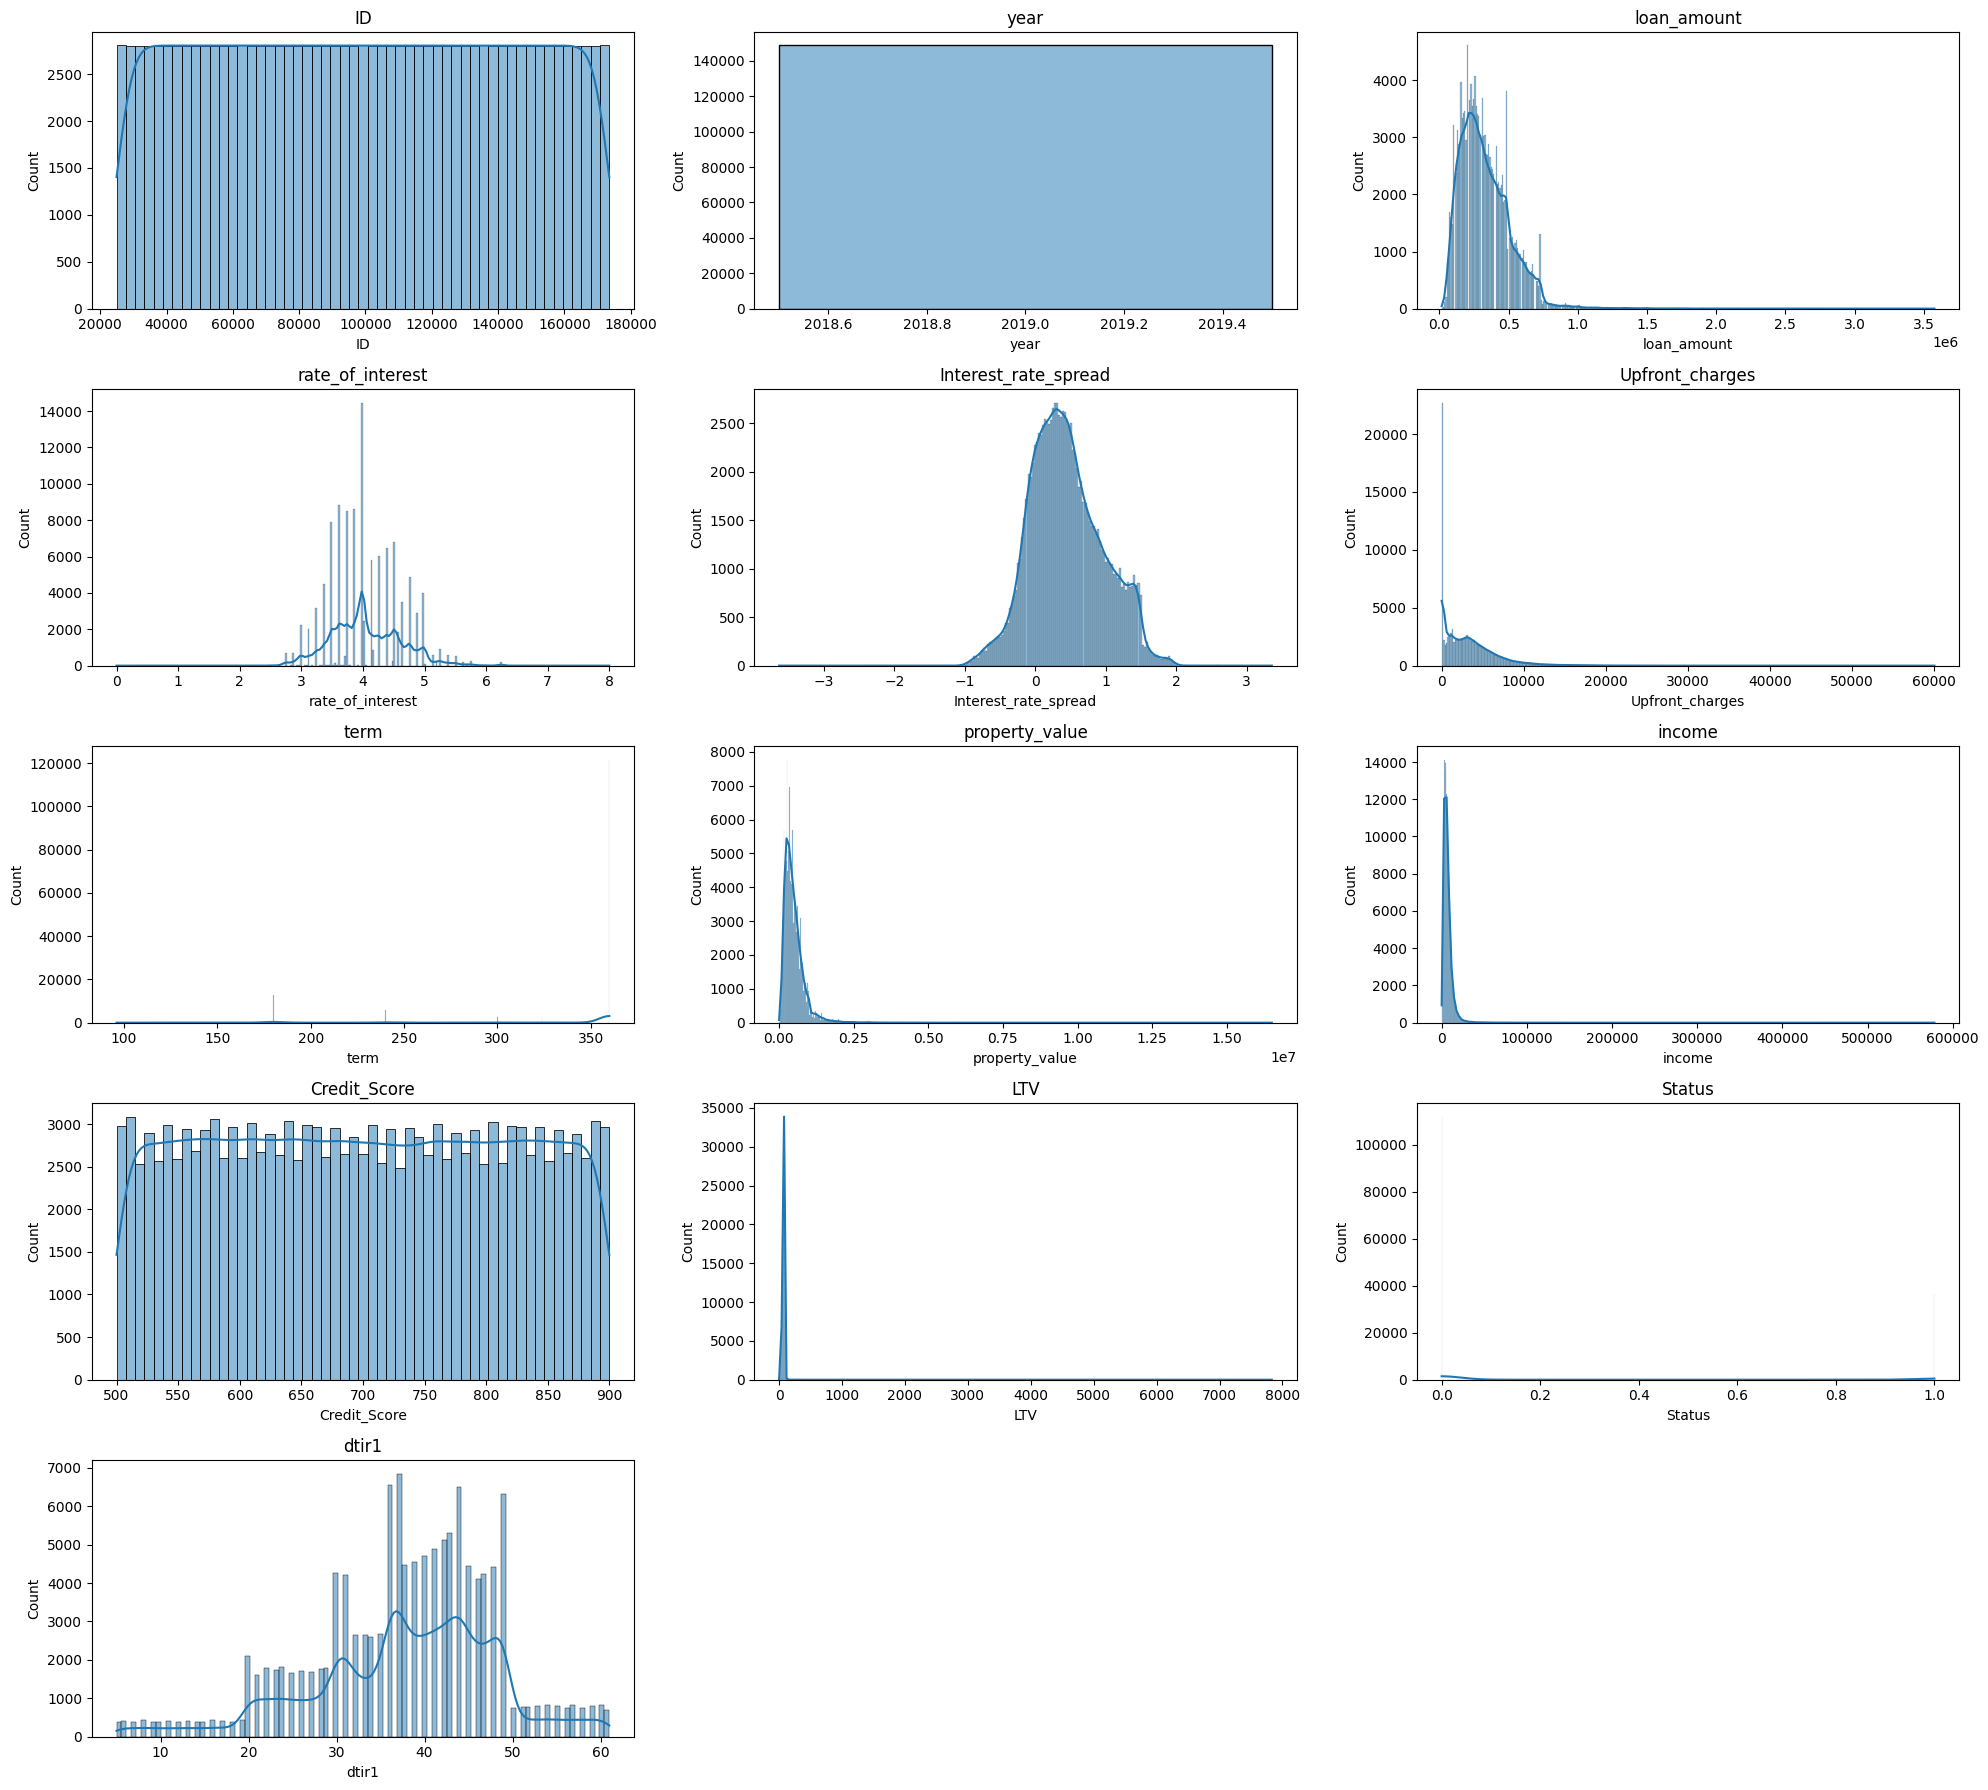

In [41]:
plt.figure(figsize=(20, 18))

num_plot_cols = num_cols.drop(['ID', 'year', 'Status'])
for i, col in enumerate(num_plot_cols):
    plt.subplot(5, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(20, 24))

for i, col in enumerate(cat_cols):
    plt.subplot(7, 3, i + 1)
    sns.countplot(x=df[col])
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#Target Varibale count plot

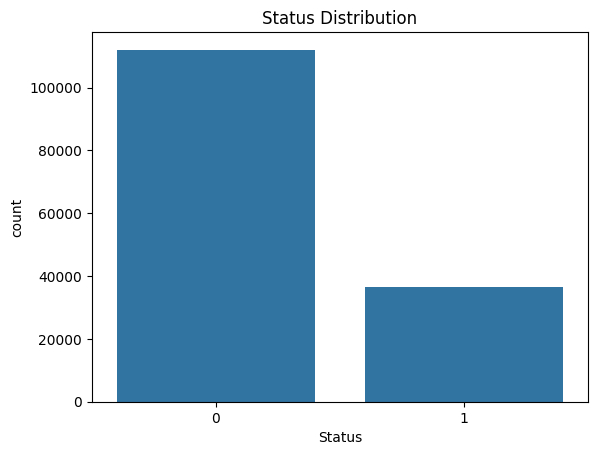

In [44]:
sns.countplot(x=df['Status'])
plt.title('Status Distribution')
plt.show()

#Outliers

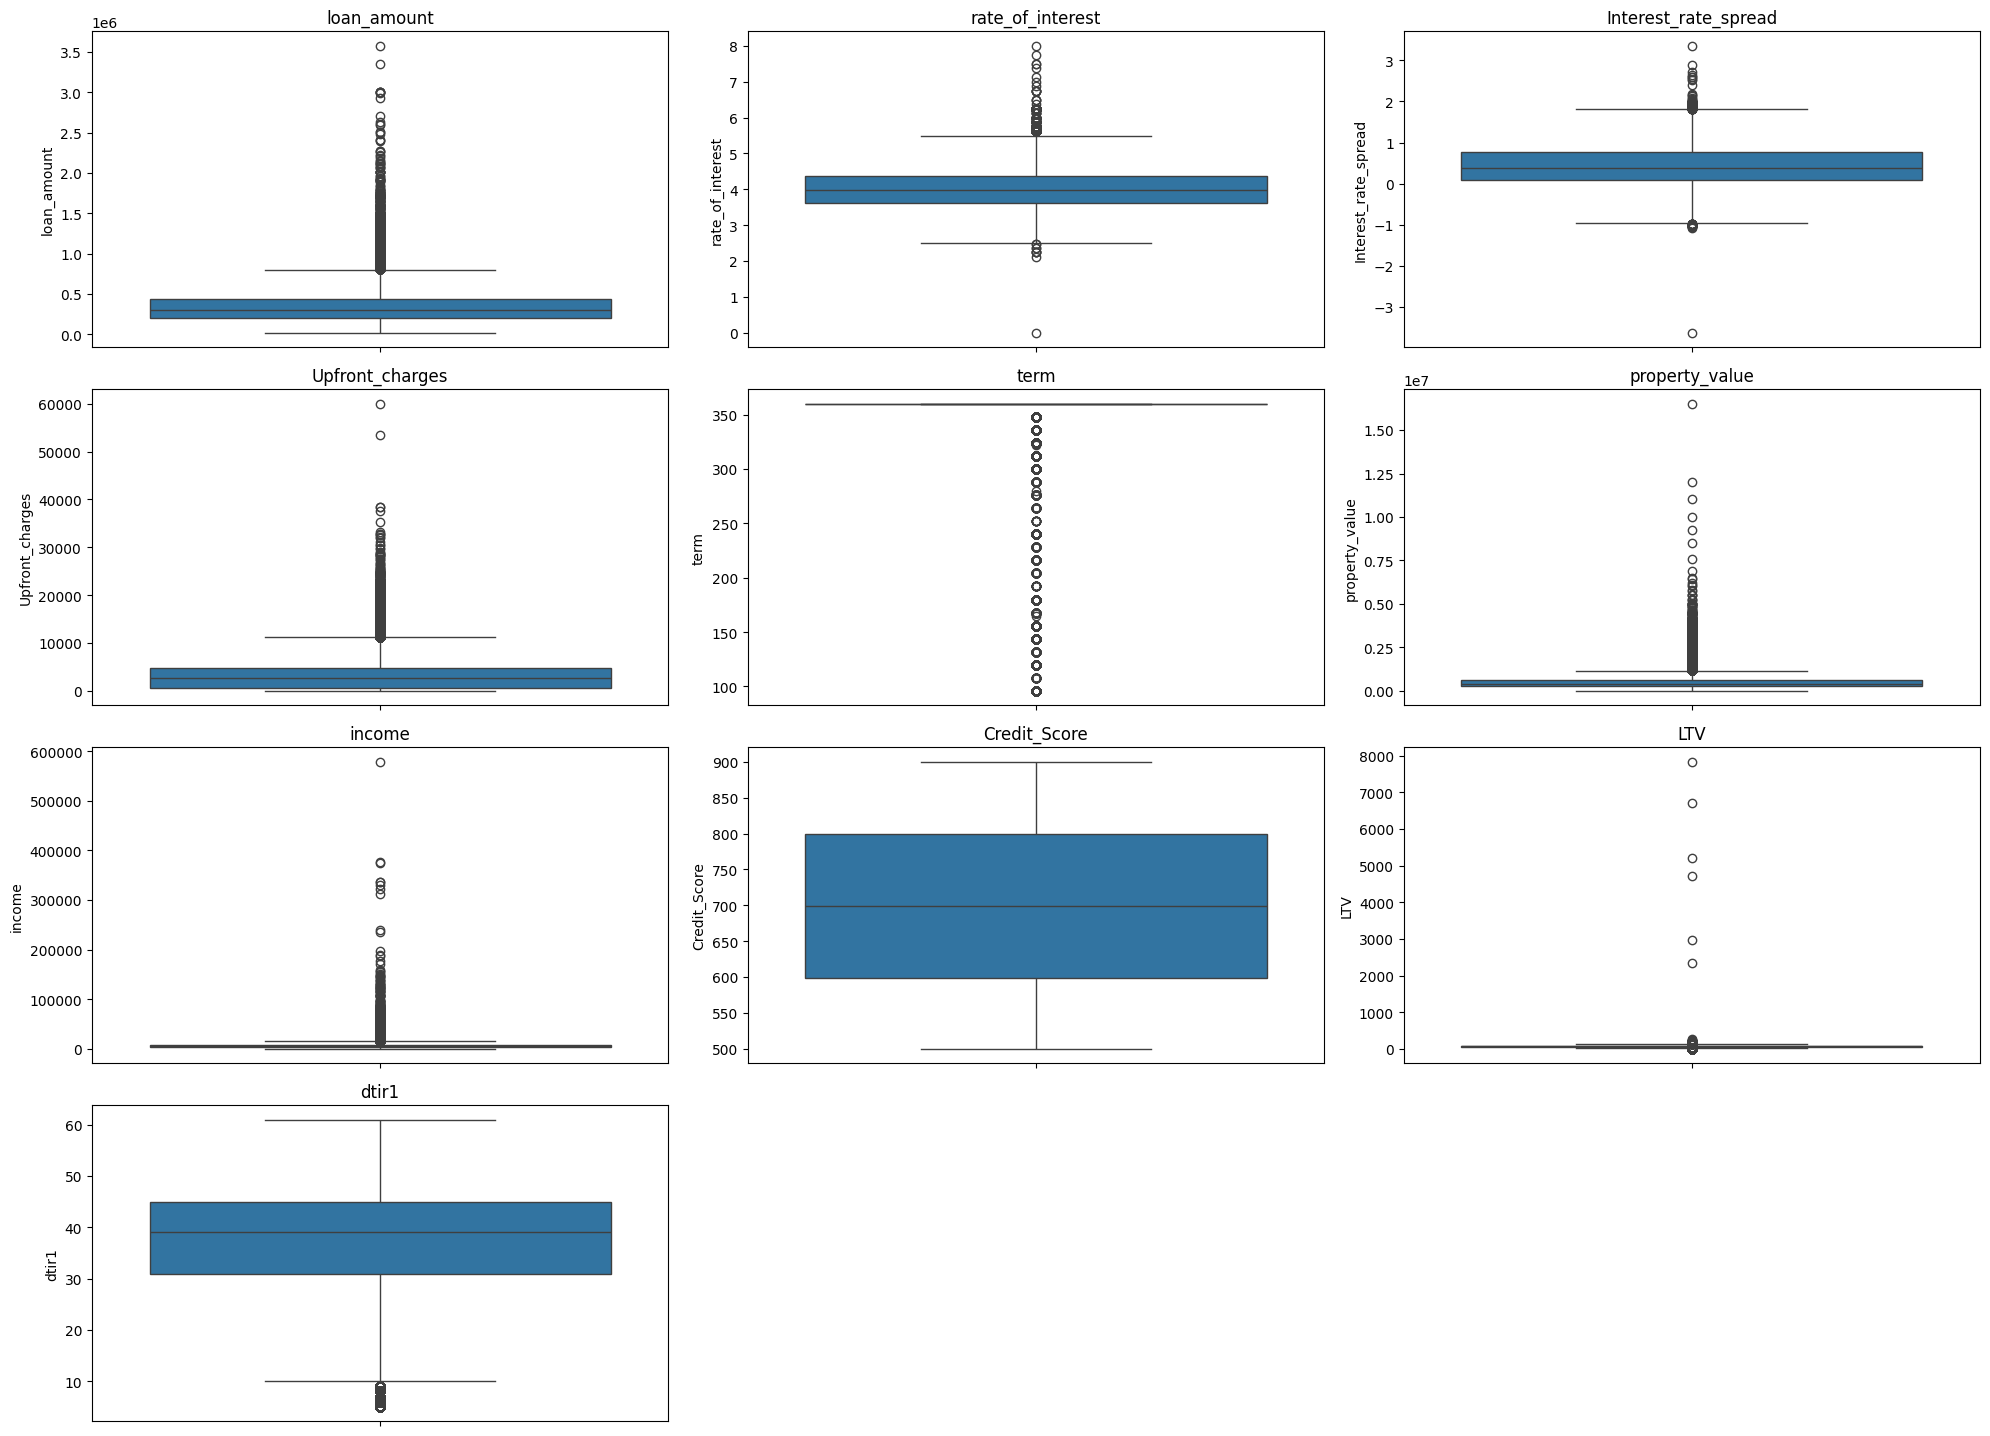

In [46]:
plt.figure(figsize=(20, 18))

num_plot_cols = num_cols.drop(['ID', 'year', 'Status'])
for i, col in enumerate(num_plot_cols):
    plt.subplot(5, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

#extreme outliers can distort the graph's scale and make the central data look compressed.

# Data Cleaning

#numerical columns were adjusted by median

In [49]:
df['rate_of_interest'] = df['rate_of_interest'].fillna(df['rate_of_interest'].median())

df['Interest_rate_spread'] = df['Interest_rate_spread'].fillna(df['Interest_rate_spread'].median())

df['Upfront_charges'] = df['Upfront_charges'].fillna(df['Upfront_charges'].median())

df['dtir1'] = df['dtir1'].fillna(df['dtir1'].median())

df['property_value'] = df['property_value'].fillna(df['property_value'].median())

df['LTV'] = df['LTV'].fillna(df['LTV'].median())

df['income'] = df['income'].fillna(df['income'].median())

df['term'] = df['term'].fillna(df['term'].median())

#For categorical columns with missing values, use mode

In [50]:
df['loan_limit'] = df['loan_limit'].fillna(df['loan_limit'].mode()[0])

df['approv_in_adv'] = df['approv_in_adv'].fillna(df['approv_in_adv'].mode()[0])

df['loan_purpose'] = df['loan_purpose'].fillna(df['loan_purpose'].mode()[0])

df['Neg_ammortization'] = df['Neg_ammortization'].fillna(df['Neg_ammortization'].mode()[0])

df['age'] = df['age'].fillna(df['age'].mode()[0])

df['submission_of_application'] = df['submission_of_application'].fillna(
    df['submission_of_application'].mode()[0]
)

In [51]:
df.isnull().sum()

ID                           0
year                         0
loan_limit                   0
Gender                       0
approv_in_adv                0
loan_type                    0
loan_purpose                 0
Credit_Worthiness            0
open_credit                  0
business_or_commercial       0
loan_amount                  0
rate_of_interest             0
Interest_rate_spread         0
Upfront_charges              0
term                         0
Neg_ammortization            0
interest_only                0
lump_sum_payment             0
property_value               0
construction_type            0
occupancy_type               0
Secured_by                   0
total_units                  0
income                       0
credit_type                  0
Credit_Score                 0
co-applicant_credit_type     0
age                          0
submission_of_application    0
LTV                          0
Region                       0
Security_Type                0
Status  

#Check for duplicated rows

In [53]:
df.duplicated().sum()

np.int64(0)

#Checking data types are correct

In [54]:
df.dtypes

ID                             int64
year                           int64
loan_limit                    object
Gender                        object
approv_in_adv                 object
loan_type                     object
loan_purpose                  object
Credit_Worthiness             object
open_credit                   object
business_or_commercial        object
loan_amount                    int64
rate_of_interest             float64
Interest_rate_spread         float64
Upfront_charges              float64
term                         float64
Neg_ammortization             object
interest_only                 object
lump_sum_payment              object
property_value               float64
construction_type             object
occupancy_type                object
Secured_by                    object
total_units                   object
income                       float64
credit_type                   object
Credit_Score                   int64
co-applicant_credit_type      object
a

#Handling in-consistent categories if any

In [55]:
for col in cat_cols:
    print(col, ":", df[col].unique())

loan_limit : ['cf' 'ncf']
Gender : ['Sex Not Available' 'Male' 'Joint' 'Female']
approv_in_adv : ['nopre' 'pre']
loan_type : ['type1' 'type2' 'type3']
loan_purpose : ['p1' 'p4' 'p3' 'p2']
Credit_Worthiness : ['l1' 'l2']
open_credit : ['nopc' 'opc']
business_or_commercial : ['nob/c' 'b/c']
Neg_ammortization : ['not_neg' 'neg_amm']
interest_only : ['not_int' 'int_only']
lump_sum_payment : ['not_lpsm' 'lpsm']
construction_type : ['sb' 'mh']
occupancy_type : ['pr' 'sr' 'ir']
Secured_by : ['home' 'land']
total_units : ['1U' '2U' '3U' '4U']
credit_type : ['EXP' 'EQUI' 'CRIF' 'CIB']
co-applicant_credit_type : ['CIB' 'EXP']
age : ['25-34' '55-64' '35-44' '45-54' '65-74' '>74' '<25']
submission_of_application : ['to_inst' 'not_inst']
Region : ['south' 'North' 'central' 'North-East']
Security_Type : ['direct' 'Indriect']


In [57]:
#Region has mixed capitalization: south, North, central, North-East
#Security_Type has Indriect, which looks like a typo for Indirect
#construction_type has ' sb' with a leading space, while 'mh' does not
#Some categories use cryptic abbreviations like pr, sr, ir, but those are not inconsistencies by themselves 
#so we need a quick fix

In [58]:
df['Region'] = df['Region'].str.title()
df['Security_Type'] = df['Security_Type'].replace('Indriect', 'Indirect')
for col in cat_cols:
    df[col] = df[col].str.strip()

In [59]:
for col in cat_cols:
    print(col, ":", df[col].unique())

loan_limit : ['cf' 'ncf']
Gender : ['Sex Not Available' 'Male' 'Joint' 'Female']
approv_in_adv : ['nopre' 'pre']
loan_type : ['type1' 'type2' 'type3']
loan_purpose : ['p1' 'p4' 'p3' 'p2']
Credit_Worthiness : ['l1' 'l2']
open_credit : ['nopc' 'opc']
business_or_commercial : ['nob/c' 'b/c']
Neg_ammortization : ['not_neg' 'neg_amm']
interest_only : ['not_int' 'int_only']
lump_sum_payment : ['not_lpsm' 'lpsm']
construction_type : ['sb' 'mh']
occupancy_type : ['pr' 'sr' 'ir']
Secured_by : ['home' 'land']
total_units : ['1U' '2U' '3U' '4U']
credit_type : ['EXP' 'EQUI' 'CRIF' 'CIB']
co-applicant_credit_type : ['CIB' 'EXP']
age : ['25-34' '55-64' '35-44' '45-54' '65-74' '>74' '<25']
submission_of_application : ['to_inst' 'not_inst']
Region : ['South' 'North' 'Central' 'North-East']
Security_Type : ['direct' 'Indirect']


#Checing for fix logic and domain errors:

In [60]:
# Domain / logical validation checks

print("loan_amount <= 0:", (df['loan_amount'] <= 0).sum())

print("property_value <= 0:", (df['property_value'] <= 0).sum())

print("income < 0:", (df['income'] < 0).sum())

print("rate_of_interest < 0:", (df['rate_of_interest'] < 0).sum())

print("term <= 0:", (df['term'] <= 0).sum())

print("LTV < 0:", (df['LTV'] < 0).sum())

print("dtir1 < 0:", (df['dtir1'] < 0).sum())

print("Invalid Status values:",
      (~df['Status'].isin([0, 1])).sum())

loan_amount <= 0: 0
property_value <= 0: 0
income < 0: 0
rate_of_interest < 0: 0
term <= 0: 0
LTV < 0: 0
dtir1 < 0: 0
Invalid Status values: 0


In [64]:
(df['income'] == 0).sum()


np.int64(1260)

In [65]:
df.nlargest(10, 'LTV')[['loan_amount', 'property_value', 'LTV']]

,loan_amount,property_value,LTV
16951,626500,8000.0,7831.250000
55286,536500,8000.0,6706.250000
47807,416500,8000.0,5206.250000
65238,376500,8000.0,4706.250000
46287,236500,8000.0,2956.250000
123343,186500,8000.0,2331.250000
43348,126500,48000.0,263.541667
27473,66500,28000.0,237.500000
30837,66500,28000.0,237.500000
136154,546500,248000.0,220.362903


#Extreme LTV values were identified. Examination showed that they result from very low property values relative to loan amounts. Since the LTV calculations are internally consistent and there is insufficient evidence that these records are wrong, they were retained.

#handling, detect outliers with IQR

In [68]:
for col in num_plot_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    print(col, ":", len(outliers))
# Outliers were detected using the IQR method.
# Since statistical outliers are not necessarily invalid values
# and no clear evidence of erroneous records was found,
# the outliers were retained.

loan_amount : 1895
rate_of_interest : 6817
Interest_rate_spread : 11478
Upfront_charges : 8915
term : 26944
property_value : 6596
income : 7636
Credit_Score : 0
LTV : 4671
dtir1 : 5508


# Data Pre-processing

In [69]:
#Label Enconding
age_mapping = {
    '<25': 0,
    '25-34': 1,
    '35-44': 2,
    '45-54': 3,
    '55-64': 4,
    '65-74': 5,
    '>74': 6
}

df['age'] = df['age'].map(age_mapping)

In [ ]:
#One hot-encoding
df = pd.get_dummies(
    df,
    columns=['Gender', 'loan_type', 'loan_purpose', 'Region'],
    dtype=int
)

In [73]:
df.shape

(148670, 45)

In [74]:
# Categories remainig 
for col in df.select_dtypes(include=['object']).columns:
    print(col, ":", df[col].unique())

loan_limit : ['cf' 'ncf']
approv_in_adv : ['nopre' 'pre']
Credit_Worthiness : ['l1' 'l2']
open_credit : ['nopc' 'opc']
business_or_commercial : ['nob/c' 'b/c']
Neg_ammortization : ['not_neg' 'neg_amm']
interest_only : ['not_int' 'int_only']
lump_sum_payment : ['not_lpsm' 'lpsm']
construction_type : ['sb' 'mh']
occupancy_type : ['pr' 'sr' 'ir']
Secured_by : ['home' 'land']
total_units : ['1U' '2U' '3U' '4U']
credit_type : ['EXP' 'EQUI' 'CRIF' 'CIB']
co-applicant_credit_type : ['CIB' 'EXP']
submission_of_application : ['to_inst' 'not_inst']
Security_Type : ['direct' 'Indirect']


In [77]:
# One-Hot Encoding remaining nominal columns
df = pd.get_dummies(
    df,
    columns=[
        'occupancy_type',
        'total_units',
        'credit_type'
    ],
    dtype=int
)

In [79]:
# Label Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

binary_cols = [
    'loan_limit',
    'approv_in_adv',
    'Credit_Worthiness',
    'open_credit',
    'business_or_commercial',
    'Neg_ammortization',
    'interest_only',
    'lump_sum_payment',
    'construction_type',
    'Secured_by',
    'co-applicant_credit_type',
    'submission_of_application',
    'Security_Type'
]

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

In [81]:
df.shape

(148670, 53)

#Now we have to scal all the columns

In [83]:
from sklearn.preprocessing import StandardScaler



scale_cols = [
    'loan_amount',
    'rate_of_interest',
    'Interest_rate_spread',
    'Upfront_charges',
    'term',
    'property_value',
    'income',
    'Credit_Score',
    'LTV',
    'dtir1'
]

scaler = StandardScaler()

df[scale_cols] = scaler.fit_transform(df[scale_cols])

In [84]:
df[scale_cols].describe()

,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,dtir1
count,1.486700e+05,1.486700e+05,1.486700e+05,1.486700e+05,1.486700e+05,1.486700e+05,1.486700e+05,1.486700e+05,1.486700e+05,1.486700e+05
mean,-1.628795e-16,-1.065312e-15,8.239562e-17,-1.554238e-16,-1.900261e-16,3.947725e-17,-2.867597e-18,1.978642e-16,1.277037e-16,3.173474e-16
std,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00
min,-1.710728e+00,-8.256195e+00,-9.120827e+00,-1.092723e+00,-4.094761e+00,-1.408627e+00,-1.092635e+00,-1.724171e+00,-1.900779e+00,-3.408589e+00
25%,-7.319814e-01,-5.772112e-01,-5.551044e-01,-6.459691e-01,4.256094e-01,-5.899639e-01,-4.831152e-01,-8.698054e-01,-2.557690e-01,-5.110537e-01
50%,-1.882333e-01,-8.575621e-02,-8.661920e-02,-1.647441e-01,4.256094e-01,-2.098702e-01,-1.783555e-01,-6.809926e-03,5.665677e-02,1.098468e-01
75%,5.730140e-01,4.466533e-01,4.282885e-01,2.973938e-01,4.256094e-01,3.164135e-01,2.216416e-01,8.648155e-01,3.096577e-01,6.272639e-01
max,1.764670e+01,8.125637e+00,6.566365e+00,2.035145e+01,4.256094e-01,4.683404e+01,9.074479e+01,1.727811e+00,2.047543e+02,2.386482e+00


# Feature Engineering and Selection

In [85]:
# Remove non-informative features
df = df.drop(columns=['ID', 'year'])

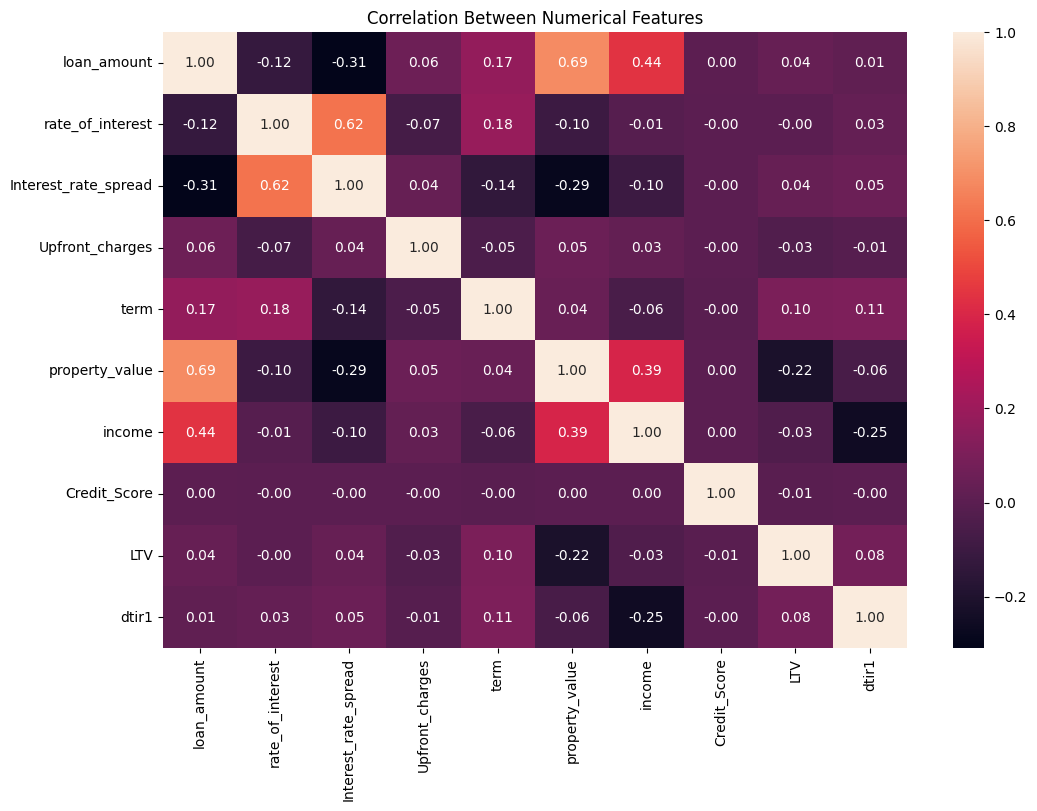

In [87]:
#Pearson correlation
num_features = [
    'loan_amount',
    'rate_of_interest',
    'Interest_rate_spread',
    'Upfront_charges',
    'term',
    'property_value',
    'income',
    'Credit_Score',
    'LTV',
    'dtir1'
]
corr = df[num_features].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f')
plt.title('Correlation Between Numerical Features')
plt.show()

In [88]:
# No numerical features were removed based on Pearson correlation,
# as no extremely high correlation was observed between feature pairs.

In [90]:
# Chi-Square Test: Categorical Features vs Target

from sklearn.feature_selection import chi2

categorical_features = [
    col for col in df.columns
    if col not in num_features + ['Status', 'ID', 'year', 'age']
]

X_cat = df[categorical_features]
y = df['Status']

chi_scores, p_values = chi2(X_cat, y)

chi_results = pd.DataFrame({
    'Feature': categorical_features,
    'Chi2 Score': chi_scores,
    'P-value': p_values
}).sort_values('P-value')

chi_results
#age is excluded because it is ordianl categorical

,Feature,Chi2 Score,P-value
10,co-applicant_credit_type,1547.716853,0.000000e+00
37,credit_type_EQUI,46768.550203,0.000000e+00
38,credit_type_EXP,1668.258891,0.000000e+00
35,credit_type_CIB,2026.387377,0.000000e+00
36,credit_type_CRIF,1672.084234,0.000000e+00
18,loan_type_type2,1095.591344,2.999734e-240
11,submission_of_application,789.008599,1.323763e-173
14,Gender_Joint,669.987977,1.005125e-147
0,loan_limit,394.478592,8.767916e-88
5,Neg_ammortization,367.402090,6.884066e-82


In [91]:
# ANOVA F-Test: Numerical Features vs Categorical Target

from sklearn.feature_selection import f_classif

X_num = df[num_features]
y = df['Status']

f_scores, p_values = f_classif(X_num, y)

anova_results = pd.DataFrame({
    'Feature': num_features,
    'F-Score': f_scores,
    'P-value': p_values
}).sort_values('P-value')

anova_results

,Feature,F-Score,P-value
3,Upfront_charges,1356.639214,1.210288e-295
9,dtir1,1017.125659,1.929235e-222
5,property_value,979.534921,2.522136e-214
6,income,548.304344,4.882970e-121
2,Interest_rate_spread,365.694332,2.031071e-81
1,rate_of_interest,325.461313,1.119591e-72
8,LTV,270.997568,7.788582e-61
0,loan_amount,201.882585,8.690628e-46
7,Credit_Score,2.383121,1.226544e-01
4,term,0.006385,9.363109e-01


In [ ]:
# Feature Selection Insights:
# 1. Pearson correlation showed no extremely high correlation among numerical features.
# 2. Chi-square showed significant associations for most categorical features,
#    while construction_type and Security_Type showed weak/no significant association.
# 3. ANOVA showed significant differences for most numerical features,
#    while term and Credit_Score were not statistically significant.
# 4. Weak features were identified as candidates rather than automatically removed,
#    because univariate statistical tests alone may not capture their combined
#    predictive value in a machine learning model.